# 05 — Prepare Data and Lock the Feature Set

**Milestone 3 · Task 6.** Confirm the target variable and encoding, decide
which features are permitted based on what a creator knows at campaign
launch, and create the training and testing splits.

**This notebook blocks tasks 7–10.** Every model built afterwards trains on
what is decided here. If the feature set changes later, every result from
tasks 7 and 8 has to be rebuilt — so the decision belongs at the start of
the milestone, not the middle.

Output: four parquet files and a documented leakage register.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loading import load_raw
from src.cleaning import clean
from src.features import (
    LEAKY_COLUMNS,
    LAUNCH_NUMERIC,
    LAUNCH_CATEGORICAL,
    CAMPAIGN_NUMERIC,
    add_location_frequency,
    add_relative_goal,
    build_features,
    build_model_matrix,
    feature_columns,
)
from src.modeling import random_split, chronological_split, split_summary

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

## 6.1 Rebuild the cleaned table

Rebuilt from the raw file rather than read from a parquet, so this notebook
is self-contained and cannot silently drift from a stale intermediate.

In [2]:
raw = load_raw("../data/DSI_kickstarterscrape_dataset_csv.zip")
clean_df, step_log = clean(raw, verbose=False)
feat = build_features(clean_df)
print(f"Cleaned and featured: {feat.shape[0]:,} rows x {feat.shape[1]} columns")
print(f"Target: success = 1 if status == 'successful'")
print(f"Class balance: {feat['success'].mean():.2%} successful")
print(f"Majority-class accuracy floor: {max(feat['success'].mean(), 1 - feat['success'].mean()):.2%}")

Cleaned and featured: 38,378 rows x 56 columns
Target: success = 1 if status == 'successful'
Class balance: 54.73% successful
Majority-class accuracy floor: 54.73%


## 6.2 Verify the target

Kickstarter is all-or-nothing: a campaign succeeds if and only if it reaches
100% of its goal. Confirm the label agrees with the funding percentage
before anything trains on it.

In [3]:
succ = feat["status"] == "successful"
pct = feat["funded_percentage"]
checks = pd.DataFrame([
    {"check": "target is binary 0/1", "result": sorted(feat["success"].unique())},
    {"check": "no missing targets", "result": int(feat["success"].isna().sum())},
    {"check": "successful but < 100% funded", "result": int((succ & (pct < 1)).sum())},
    {"check": "failed but >= 100% funded", "result": int((~succ & (pct >= 1)).sum())},
])
print(checks.to_string(index=False))
print(f"\nLabel agreement: {100 * (1 - ((succ & (pct < 1)) | (~succ & (pct >= 1))).mean()):.2f}%")

                       check result
        target is binary 0/1 [0, 1]
          no missing targets      0
successful but < 100% funded      1
   failed but >= 100% funded      2

Label agreement: 99.99%


## 6.3 The leakage register

Every column excluded from modelling, with the reason. This is the artefact
to show the Challenge Advisor — it makes the feature-set decision explicit
and reviewable rather than buried in code.

In [4]:
pd.DataFrame([{"column": k, "reason for exclusion": v} for k, v in LEAKY_COLUMNS.items()])

,column,reason for exclusion
0,pledged,Dollars raised. This IS the outcome.
1,funded_percentage,pledged / goal. Mechanically determines success.
2,backers,Count of people who pledged. Pure outcome.
3,comments,Audience-generated volume; scales with backers.
4,status,The raw target.
5,success,The encoded target.
6,funded_date,Campaign END date; unknown at launch.
7,end_date,Parsed campaign end; unknown at launch.
8,url,"Identifier, not a feature."
9,project_id,"Identifier, not a feature."


### The three tiers

**Outcome columns — excluded unconditionally.** `pledged`,
`funded_percentage`, `backers`, `comments`. These are results, not inputs.
`funded_percentage` *mechanically determines* the target, so including it
yields a ~100% accurate model that has learned division.

**Campaign-time columns — the open decision.** `updates` counts creator
posts made *during* the campaign. It is the single strongest signal in the
dataset and it is zero on launch day for every campaign.

**Launch-time columns — permitted.** Everything a creator has decided by the
moment they press publish.

In [5]:
print("LAUNCH-TIME FEATURES (permitted)")
print(f"  numeric     ({len(LAUNCH_NUMERIC)}): {', '.join(LAUNCH_NUMERIC)}")
print(f"  categorical ({len(LAUNCH_CATEGORICAL)}): {', '.join(LAUNCH_CATEGORICAL)}")
print(f"\nCAMPAIGN-TIME FEATURES (decision required)")
print(f"  {', '.join(CAMPAIGN_NUMERIC)}")
print(f"\nEXCLUDED OUTCOMES")
print(f"  pledged, funded_percentage, backers, comments")

LAUNCH-TIME FEATURES (permitted)
  numeric     (22): log_goal, goal_is_round_1k, duration_days, is_30_day, log_goal_per_day, levels, n_tiers_parsed, log_min_tier, log_max_tier, median_tier, tier_spread, min_tier_pct_of_goal, log_goal_per_tier, launch_year, launch_month, launch_dow, launch_is_weekend, name_length, name_word_count, name_has_exclaim, name_has_digit, name_upper_ratio
  categorical (3): category, subcategory, state_raw

CAMPAIGN-TIME FEATURES (decision required)
  updates

EXCLUDED OUTCOMES
  pledged, funded_percentage, backers, comments


## 6.4 Evidence for the `updates` decision

Restated here so the decision is made against the numbers rather than from
memory of the September notebook.

In [6]:
upd = feat.groupby(pd.cut(feat["updates"], [-1, 0, 1, 3, 6, 12, 1000],
                          labels=["0", "1", "2-3", "4-6", "7-12", "13+"]),
                   observed=True)["success"].agg(["mean", "size"])
upd.columns = ["success_rate", "n"]
print(upd.round(3).to_string())
print(f"\nSpearman(updates, success) = "
      f"{feat['updates'].corr(feat['success'], method='spearman'):.3f}")
print(f"Spearman(log_goal, success) = "
      f"{feat['log_goal'].corr(feat['success'], method='spearman'):.3f}  <- next strongest")

         success_rate      n
updates                     
0               0.204  12702
1               0.435   4796
2-3             0.641   6215
4-6             0.782   6110
7-12            0.865   5330
13+             0.918   3225

Spearman(updates, success) = 0.552
Spearman(log_goal, success) = -0.261  <- next strongest


**Decision (pending advisor confirmation):** `updates` is excluded from the
primary feature set.

Three reasons:

1. **Unavailable at prediction time.** Zero on launch day for every
   campaign, so a model relying on it cannot answer *"should I launch this,
   like this, today?"*
2. **Causation is ambiguous and likely partly reversed.** A campaign that is
   visibly funding well attracts a creator who keeps posting; a stalling one
   goes quiet. "Post more updates" may be advice that does nothing.
3. **It would dominate.** At roughly three times the rank correlation of the
   next strongest feature, it crowds out signal the creator can actually act
   on — which is what Milestone 4 needs.

**Both feature sets are carried forward** so the cost of the decision can be
measured in Task 8 rather than asserted. `plus_campaign` is reported as a
clearly-labelled *mid-campaign* model — a legitimate second product for
triaging campaigns already running — and never as a pre-launch predictor.

In [7]:
for fs in ["launch_only", "plus_campaign"]:
    num, cat = feature_columns(fs)
    print(f"{fs:16s} {len(num)} numeric + {len(cat)} categorical")

launch_only      22 numeric + 3 categorical
plus_campaign    23 numeric + 3 categorical


## 6.5 Create both splits

**Random stratified** is the standard comparison. **Chronological** trains
on earlier campaigns and tests on later ones, which is the actual deployment
scenario — a random split lets the model learn from 2012 campaigns to
predict 2010 ones, which it could never do in practice.

In [8]:
rand_train, rand_test = random_split(feat)
chron_train, chron_test = chronological_split(feat)

summaries = pd.concat([
    split_summary(rand_train, rand_test, "random"),
    split_summary(chron_train, chron_test, "chronological"),
], ignore_index=True)
summaries

,split,train_n,test_n,train_success_rate,test_success_rate,train_end,test_start
0,random,30702,7676,0.5474,0.5473,2012-05-29,2009-04-28
1,chronological,30702,7676,0.5505,0.5349,2012-02-11,2012-02-11


Note the chronological split's class balance. If the test period's success
rate differs from the training period's, the platform itself changed — and
any accuracy drop under this split is partly that drift rather than model
failure. Worth stating in the write-up.

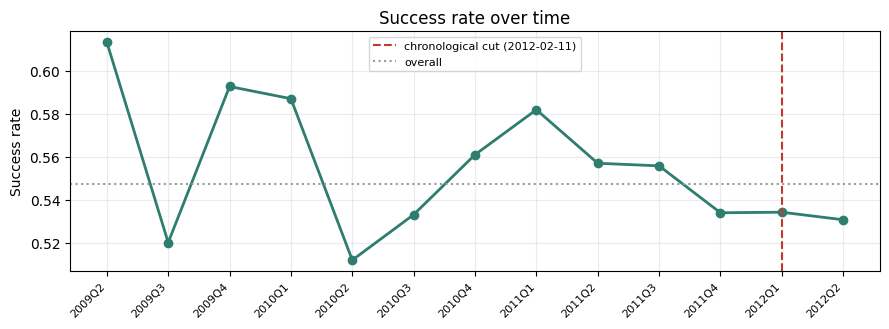

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.4))
yearly = feat.groupby(feat["launch_date"].dt.to_period("Q"), observed=True)["success"].agg(["mean", "size"])
yearly.index = yearly.index.astype(str)
ax.plot(range(len(yearly)), yearly["mean"], marker="o", color="#2E7D6F", lw=2)
cut_date = chron_test["launch_date"].min()
cut_q = str(cut_date.to_period("Q"))
if cut_q in list(yearly.index):
    ax.axvline(list(yearly.index).index(cut_q), color="#C0392B", ls="--",
               label=f"chronological cut ({cut_date.date()})")
ax.axhline(feat["success"].mean(), color="#999", ls=":", label="overall")
ax.set_xticks(range(len(yearly)))
ax.set_xticklabels(yearly.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Success rate"); ax.set_title("Success rate over time")
ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("../reports/figures/success_rate_over_time.png", dpi=130, bbox_inches="tight")
plt.show()

## 6.6 Fit the stateful features on training data only

Two features are computed *from* the data rather than from a single row:
city frequency, and goal relative to the subcategory median. Computing
either over the full dataset lets test rows influence a training feature.
The reference objects are fitted on train and applied to test.

In [10]:
def prepare(train, test):
    train, city_ref = add_location_frequency(train)
    train, goal_ref = add_relative_goal(train)
    test, _ = add_location_frequency(test, reference=city_ref)
    test, _ = add_relative_goal(test, reference=goal_ref)
    return train, test

rand_train, rand_test = prepare(rand_train, rand_test)
chron_train, chron_test = prepare(chron_train, chron_test)

print(f"Random split   — unseen test cities: {(rand_test['city_project_count'] == 0).sum():,}")
print(f"Chronological  — unseen test cities: {(chron_test['city_project_count'] == 0).sum():,}")
print("\nUnseen cities correctly encode to 0 rather than borrowing a training value.")

Random split   — unseen test cities: 453
Chronological  — unseen test cities: 662

Unseen cities correctly encode to 0 rather than borrowing a training value.


## 6.7 Verify the encoded matrices

Confirm the encoding works and that the leakage guard actually fires.

In [11]:
EXTRA = ["log_city_project_count", "log_goal_vs_subcat_median"]

for fs in ["launch_only", "plus_campaign"]:
    X, y = build_model_matrix(rand_train, fs, extra_numeric=EXTRA)
    all_float = bool((X.dtypes == "float64").all())
    print(f"{fs:16s} X shape {X.shape}   nulls {int(X.isna().sum().sum())}   "
          f"all float64: {all_float}")

launch_only      X shape (30702, 137)   nulls 0   all float64: True
plus_campaign    X shape (30702, 138)   nulls 0   all float64: True


In [12]:
try:
    build_model_matrix(rand_train, "launch_only",
                       extra_numeric=["pledged", "backers", "funded_percentage"])
    print("WARNING: leakage guard did not fire")
except ValueError as e:
    print(f"Leakage guard fired correctly:\n  {e}")

Leakage guard fired correctly:
  Leaky columns requested: ['backers', 'funded_percentage', 'pledged']


## 6.8 Save the splits

Tasks 7–10 read these files. Everyone on the team works from the same rows,
so results are comparable without re-deriving anything.

In [13]:
out = Path("../data")
rand_train.to_parquet(out / "m3_random_train.parquet", index=False)
rand_test.to_parquet(out / "m3_random_test.parquet", index=False)
chron_train.to_parquet(out / "m3_chrono_train.parquet", index=False)
chron_test.to_parquet(out / "m3_chrono_test.parquet", index=False)
summaries.to_csv("../reports/m3_split_summary.csv", index=False)

pd.DataFrame(
    [{"column": k, "reason": v} for k, v in LEAKY_COLUMNS.items()]
).to_csv("../reports/m3_leakage_register.csv", index=False)

print("Wrote 4 parquet splits to ../data/")
print("Wrote m3_split_summary.csv and m3_leakage_register.csv to ../reports/")

Wrote 4 parquet splits to ../data/
Wrote m3_split_summary.csv and m3_leakage_register.csv to ../reports/


## Task 6 — Summary

| Item | Decision |
|---|---|
| Target | `success` = 1 if `status == "successful"`, verified against funding % |
| Majority-class floor | **54.7%** — every model must beat this |
| Excluded outcomes | `pledged`, `funded_percentage`, `backers`, `comments` |
| `updates` | Excluded from the primary set; carried as a labelled mid-campaign variant |
| Primary feature set | `launch_only` — 21 numeric + 3 categorical + 2 fitted |
| Encoding | One-hot for category/subcategory/state; frequency for city |
| Splits | Random stratified 80/20 **and** chronological |
| Stateful features | Fitted on train, applied to test |

### Open item for the Challenge Advisor

The published benchmark for this dataset (80.2% accuracy, F1 0.834) was
produced with `updates` included. Excluding it means the primary model will
likely land below the 80% target. Task 8 quantifies the gap exactly.

**Question:** is a lower headline number acceptable on the primary model,
given that it is the only version able to inform a pre-launch decision?

### Ready for handoff

Tasks 7–10 can now proceed in parallel. Each model in Task 7 reads the same
parquet splits and reports through `src.evaluation.evaluate()`, so results
concatenate into one table without reconciliation.